In [14]:
# TASK 1: BUILD A MODEL FOR SENTIMENT ANALYSIS

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [10]:
df = pd.read_csv("../datasets/1429_1.csv")

C:\Users\sandv\AppData\Local\Temp\ipykernel_15392\2983328222.py:1: DtypeWarning: Columns (1: name, 10: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../datasets/1429_1.csv")


In [11]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [12]:
df.shape

(34660, 21)

In [13]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='str')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  str    
 1   name                  27900 non-null  str    
 2   asins                 34658 non-null  str    
 3   brand                 34660 non-null  str    
 4   categories            34660 non-null  str    
 5   keys                  34660 non-null  str    
 6   manufacturer          34660 non-null  str    
 7   reviews.date          34621 non-null  str    
 8   reviews.dateAdded     24039 non-null  str    
 9   reviews.dateSeen      34660 non-null  str    
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs    34660 no

In [15]:
df[["reviews.text", "reviews.rating"]].head(10)

,reviews.text,reviews.rating
0,This product so far has not disappointed. My c...,5.0
1,great for beginner or experienced person. Boug...,5.0
2,Inexpensive tablet for him to use and learn on...,5.0
3,I've had my Fire HD 8 two weeks now and I love...,4.0
4,I bought this for my grand daughter when she c...,5.0
5,This amazon fire 8 inch tablet is the perfect ...,5.0
6,"Great for e-reading on the go, nice and light ...",4.0
7,"I gave this as a Christmas gift to my inlaws, ...",5.0
8,Great as a device to read books. I like that i...,5.0
9,I love ordering books and reading them with th...,5.0


In [22]:
df["reviews.rating"].value_counts().sort_index()

reviews.rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23775
Name: count, dtype: int64

In [23]:
df[df["reviews.rating"].isna()][["reviews.text", "reviews.rating"]]

,reviews.text,reviews.rating
2886,The Kindle is my first e-ink reader. I own an ...,NaN
2887,"I'm a first-time Kindle owner, so I have nothi...",NaN
2888,UPDATE NOVEMBER 2011:My review is now over a y...,NaN
2889,"I'm a first-time Kindle owner, so I have nothi...",NaN
2890,I woke up to a nice surprise this morning: a n...,NaN
2891,The Kindle is my first e-ink reader. I own an ...,NaN
2892,UPDATE NOVEMBER 2011:br /br /My review is now ...,NaN
2893,I woke up to a nice surprise this morning: a n...,NaN
2894,I use to hate to read but now that I have my K...,NaN
2895,All of them quit working. There's absolutely n...,NaN


In [19]:
df_clean = df.dropna(subset=["reviews.rating"]).copy()

In [20]:
df_clean.shape

(34627, 21)

In [21]:
df_clean.nunique().sort_values()

reviews.userCity            0
reviews.userProvince        0
reviews.id                  1
reviews.didPurchase         1
manufacturer                2
reviews.doRecommend         2
reviews.rating              5
brand                       5
categories                 38
asins                      38
id                         39
keys                       39
name                       48
reviews.numHelpful         97
reviews.date             1061
reviews.dateAdded        1941
reviews.dateSeen         3898
reviews.sourceURLs      11923
reviews.title           19745
reviews.username        26765
reviews.text            34626
dtype: int64

In [27]:
for col in df.columns:
    print(col)

id
name
asins
brand
categories
keys
manufacturer
reviews.date
reviews.dateAdded
reviews.dateSeen
reviews.didPurchase
reviews.doRecommend
reviews.id
reviews.numHelpful
reviews.rating
reviews.sourceURLs
reviews.text
reviews.title
reviews.userCity
reviews.userProvince
reviews.username


In [28]:
df.notna().sum()

id                      34660
name                    27900
asins                   34658
brand                   34660
categories              34660
keys                    34660
manufacturer            34660
reviews.date            34621
reviews.dateAdded       24039
reviews.dateSeen        34660
reviews.didPurchase         1
reviews.doRecommend     34066
reviews.id                  1
reviews.numHelpful      34131
reviews.rating          34627
reviews.sourceURLs      34660
reviews.text            34659
reviews.title           34654
reviews.userCity            0
reviews.userProvince        0
reviews.username        34653
dtype: int64

In [22]:
df_project = df_clean[[
    "reviews.rating",
    "reviews.text",
    "reviews.title",
    "name",
    "brand",
    "categories"
]].copy()

In [23]:
df_project.columns

Index(['reviews.rating', 'reviews.text', 'reviews.title', 'name', 'brand',
       'categories'],
      dtype='str')

In [31]:
df_project.shape

(34627, 6)

In [24]:
df_project.head()

,reviews.rating,reviews.text,reviews.title,name,brand,categories
0,5.0,This product so far has not disappointed. My c...,Kindle,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
1,5.0,great for beginner or experienced person. Boug...,very fast,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
2,5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
3,4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
4,5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."


In [25]:
df_project.isnull().sum()

reviews.rating       0
reviews.text         1
reviews.title        6
name              6759
brand                0
categories           0
dtype: int64

In [26]:
df_project_clean = df_project.copy()

In [35]:
df_project_clean = df_project_clean.dropna(
    subset=[
        "reviews.text",
        "reviews.rating"
    ]
)

In [36]:
df_project_clean.duplicated().sum()

np.int64(0)

In [37]:
(df_project_clean["reviews.text"].str.strip() == "").sum()

np.int64(0)

In [33]:
df_project_clean["reviews.rating"].value_counts().sort_index()

reviews.rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23775
Name: count, dtype: int64

In [34]:
def map_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df_project_clean["sentiment"] = df_project_clean["reviews.rating"].apply(map_sentiment)

In [35]:
df_project_clean["sentiment"].value_counts()

sentiment
positive    32316
neutral      1499
negative      812
Name: count, dtype: int64

In [36]:
df_project_clean.groupby("sentiment")[[
    "reviews.title",
    "reviews.text",
    "reviews.rating"
]].sample(3, random_state=42)

,reviews.title,reviews.text,reviews.rating
8633,Not great at all,When I first got it was great until it stopped...,1.0
21614,NO WARRANTY COVERAGE,charging port fault appeared in tablet after 2...,1.0
8168,You get what you pay for.,You get what you pay for. It works but is very...,2.0
14360,kindle used as a kids tablet,Well primarily I was going. To for a Samsung g...,3.0
29590,Just OK,I bought this and an AppleTV at the same time....,3.0
22554,Music for listening pleasure was good.,"The music was good, however, Alexa's voice was...",3.0
20465,Excellent Product,Exactly as discribed. Love the product! I woul...,5.0
2009,Great Tablet,Was looking for a tablet with expandable memor...,5.0
3850,Great product!,Such a great tablet! Got my mother it for Chri...,5.0


In [37]:
df_project_clean["review"] = (
    df_project_clean["reviews.title"].fillna("") + " " +
    df_project_clean["reviews.text"].fillna("")
)

In [38]:
df_project_clean[[
    "reviews.title",
    "reviews.text",
    "review",
    "sentiment"
]].head()

,reviews.title,reviews.text,review,sentiment
0,Kindle,This product so far has not disappointed. My c...,Kindle This product so far has not disappointe...,positive
1,very fast,great for beginner or experienced person. Boug...,very fast great for beginner or experienced pe...,positive
2,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son. Inexpe...,positive
3,Good!!!,I've had my Fire HD 8 two weeks now and I love...,Good!!! I've had my Fire HD 8 two weeks now an...,positive
4,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,Fantastic Tablet for kids I bought this for my...,positive


In [39]:
(df_project_clean["review"].str.strip() == "").sum()

np.int64(0)

In [40]:
df_project_clean["review"].str.len().describe()

count    34627.000000
mean       178.187628
std        184.966869
min         11.000000
25%         88.000000
50%        126.000000
75%        205.000000
max      10723.000000
Name: review, dtype: float64

In [41]:
X = df_project_clean["review"]
y = df_project_clean["sentiment"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
print("Train:", len(X_train))
print("Test:", len(X_test))

print("\nDistribuzione TRAIN:")
print(y_train.value_counts())

print("\nDistribuzione TEST:")
print(y_test.value_counts())

Train: 27701
Test: 6926

Distribuzione TRAIN:
sentiment
positive    25852
neutral      1199
negative      650
Name: count, dtype: int64

Distribuzione TEST:
sentiment
positive    6464
neutral      300
negative     162
Name: count, dtype: int64


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

In [44]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [51]:
print("Train TF-IDF:", X_train_tfidf.shape)
print("Test TF-IDF:", X_test_tfidf.shape)

Train TF-IDF: (27700, 10000)
Test TF-IDF: (6926, 10000)


In [46]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [47]:
model.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [54]:
predictions = model.predict(
    X_test_tfidf)

In [55]:
accuracy = accuracy_score(
    y_test,
    predictions
)
print("Accuracy:", accuracy)

Accuracy: 0.8847819809413803


In [56]:
y_pred = model.predict(X_test_tfidf)

In [57]:
print(len(y_pred))

6926


In [58]:
for i in range(10):
    print("REVIEW:", X_test.iloc[i])
    print("REALE:", y_test.iloc[i])
    print("PRED:", y_pred[i])
    print("-" * 80)

REVIEW: great product Love white background and. back lighting. Much easier to read than earlier models
REALE: positive
PRED: positive
--------------------------------------------------------------------------------
REVIEW: great product Easy to use. Great price. Easy to setup. Small size
REALE: positive
PRED: positive
--------------------------------------------------------------------------------
REVIEW: Worth it if you root it to cyanogenmod Root to cyanogenmod and it becomes a good inexpensive android tablet.
REALE: positive
PRED: neutral
--------------------------------------------------------------------------------
REVIEW: Nice for the price!!! I purchased this tablet mainly because of the price so I am pleased with the functions that it offers...mainly accessing the internet and games.
REALE: positive
PRED: positive
--------------------------------------------------------------------------------
REVIEW: Definitely worth the buy Minimizes buffering, don't have to have wireless i

In [59]:
accuracy = accuracy_score(
    y_test,
    predictions
)
print("Accuracy:", accuracy)
print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy: 0.8847819809413803
              precision    recall  f1-score   support

    negative       0.42      0.65      0.51       162
     neutral       0.22      0.52      0.31       300
    positive       0.98      0.91      0.94      6464

    accuracy                           0.88      6926
   macro avg       0.54      0.69      0.59      6926
weighted avg       0.93      0.88      0.91      6926



In [60]:
cm = confusion_matrix(
    y_test,
    predictions
)
cm

array([[ 105,   36,   21],
       [  50,  156,   94],
       [  93,  504, 5867]])

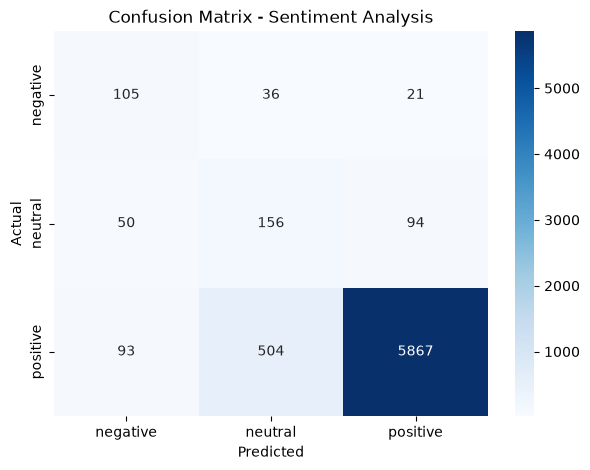

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Sentiment Analysis")

plt.show()

In [62]:
error_mask = (y_test == "positive") & (predictions == "neutral")

pd.DataFrame({
    "review": X_test[error_mask],
    "actual": y_test[error_mask],
    "predicted": predictions[error_mask]
}).head(10)

,review,actual,predicted
7840,Worth it if you root it to cyanogenmod Root to...,positive,neutral
2363,great for the kids I would recommend this to o...,positive,neutral
8363,Nice Starter Tab This is a great beginner tabl...,positive,neutral
11554,It's a good tablet for $39.00 It is great tabl...,positive,neutral
32565,Decent Product There are a few things I like a...,positive,neutral
2775,"Great inexpensive tablet Inexpensive, but well...",positive,neutral
12768,kindle I bought it for a gift and the recipien...,positive,neutral
4451,"Nice little tablet, but a manual would be help...",positive,neutral
16504,Good bargain My 5 year old grandson really enj...,positive,neutral
33408,I like with reservations I do like the Amazon ...,positive,neutral


In [63]:
# What happened here?

# The model performs very well on the majority class, positive, correctly classifying 6469 out of 6491 positive reviews.

# However, performance is much weaker for negative and neutral reviews. Only 20 negative and 21 neutral reviews were correctly classified, while many were incorrectly predicted as positive.

# This is mainly explained by the strong class imbalance in the dataset:

# Positive: 32,315
# Neutral: 1,499
# Negative: 812

# Even with class weighting, the model still struggles to distinguish the minority classes from positive reviews.

# Therefore, the 94% accuracy alone is misleading: the model is very good at recognizing positive reviews, but much less reliable for neutral and negative sentiment.

# Baseline Model Results
# This Task 1 model, although not perfect, serves as the baseline sentiment classification model so for now it is good.

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

In [65]:
C_values = [0.1, 0.5, 1, 2, 5]

results = []

for C in C_values:
    model_test = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight="balanced"
    )

    model_test.fit(X_train_tfidf, y_train)

    predictions_test = model_test.predict(X_test_tfidf)

    macro_f1 = f1_score(
        y_test,
        predictions_test,
        average="macro"
    )

    results.append({
        "C": C,
        "macro_f1": macro_f1
    })

results

[{'C': 0.1, 'macro_f1': 0.54485476674686},
 {'C': 0.5, 'macro_f1': 0.5824699923178},
 {'C': 1, 'macro_f1': 0.5894136663923265},
 {'C': 2, 'macro_f1': 0.5954651939030452},
 {'C': 5, 'macro_f1': 0.595724279271529}]

In [66]:
C_values = [5, 10, 20, 50]

results_more = []

for C in C_values:
    model_test = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight="balanced"
    )

    model_test.fit(X_train_tfidf, y_train)

    predictions_test = model_test.predict(X_test_tfidf)

    macro_f1 = f1_score(
        y_test,
        predictions_test,
        average="macro"
    )

    results_more.append({
        "C": C,
        "macro_f1": macro_f1
    })

results_more

[{'C': 5, 'macro_f1': 0.595724279271529},
 {'C': 10, 'macro_f1': 0.5989592507201742},
 {'C': 20, 'macro_f1': 0.5969375887315821},
 {'C': 50, 'macro_f1': 0.5944383570866125}]

In [67]:
optimized_model = LogisticRegression(
    C=50,
    max_iter=1000,
    class_weight="balanced"
)

optimized_model.fit(X_train_tfidf, y_train)

optimized_predictions = optimized_model.predict(X_test_tfidf)


print(
    classification_report(
        y_test,
        optimized_predictions
    )
)

              precision    recall  f1-score   support

    negative       0.47      0.54      0.51       162
     neutral       0.28      0.36      0.32       300
    positive       0.97      0.95      0.96      6464

    accuracy                           0.92      6926
   macro avg       0.57      0.62      0.59      6926
weighted avg       0.93      0.92      0.92      6926



In [68]:
# At the end of task n.1:

# The optimized Logistic Regression model achieved 92% accuracy and a macro F1-score of 0.60.
# Performance was excellent for the majority Positive class but weaker for Neutral and Negative reviews.
# Using `class_weight="balanced"` helped address the severe class imbalance.
# Optimizing the C parameter improved overall performance compared with the baseline model.
# Overall, the model provides a solid and reliable baseline for sentiment classification.



In [69]:
# BAG OF WORDS (to compare vs Tf-IDF log. regr.)

from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [70]:
from sklearn.linear_model import LogisticRegression

bow_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

bow_model.fit(X_train_bow, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [71]:
bow_predictions = bow_model.predict(X_test_bow)

In [72]:
from sklearn.metrics import accuracy_score, classification_report

print("BoW Accuracy:", accuracy_score(y_test, bow_predictions))
print()
print(classification_report(y_test, bow_predictions))

BoW Accuracy: 0.9139474444123592

              precision    recall  f1-score   support

    negative       0.45      0.55      0.50       162
     neutral       0.28      0.41      0.33       300
    positive       0.97      0.95      0.96      6464

    accuracy                           0.91      6926
   macro avg       0.57      0.63      0.60      6926
weighted avg       0.93      0.91      0.92      6926



In [73]:
# The Bag of Words model achieved 91.4% accuracy and a macro F1-score of 0.59.
# Its performance was slightly lower than the TF-IDF model, which achieved 92.0% accuracy and a macro F1-score of 0.60.
# Overall, TF-IDF performed slightly better, suggesting that weighting words by their importance is more effective for this dataset.

In [74]:
# TRIAL WITH A THIRD MODEL (to compare vs Tf-IDF log. regr. and BoW log. regr.) -> DISTILBERT

In [75]:
import platform
import psutil

print("CPU:", platform.processor())
print("RAM:", round(psutil.virtual_memory().total / (1024**3), 1), "GB")

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except ImportError:
    print("PyTorch: not installed")

CPU: Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
RAM: 15.6 GB


PyTorch: 2.14.1+cpu
CUDA available: False


In [76]:
import sys
print(sys.executable)

c:\Users\sandv\OneDrive\Plocha\IVAN\IRON HACK\.ipynb dal corso\w4\venv\Scripts\python.exe


In [77]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Transformers OK")

c:\Users\sandv\OneDrive\Plocha\IVAN\IRON HACK\.ipynb dal corso\w4\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers OK


In [78]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded")

Tokenizer loaded


In [79]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

print("Model loaded")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 499.92it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


In [80]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

print(label2id)

{'negative': 0, 'neutral': 1, 'positive': 2}


In [81]:
import pandas as pd

df = pd.read_csv("../datasets/1429_1.csv")

df_clean = df.dropna(subset=["reviews.rating"]).copy()

df_project = df_clean[[
    "reviews.rating",
    "reviews.text",
    "reviews.title",
    "name",
    "brand",
    "categories"
]].copy()

df_project_clean = df_project.dropna(
    subset=["reviews.text", "reviews.rating"]
).copy()

def map_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df_project_clean["sentiment"] = (
    df_project_clean["reviews.rating"].apply(map_sentiment)
)

df_project_clean["review"] = (
    df_project_clean["reviews.title"].fillna("") + " " +
    df_project_clean["reviews.text"].fillna("")
)

print("Rows:", len(df_project_clean))
print(df_project_clean["sentiment"].value_counts())

Rows: 34626
sentiment
positive    32315
neutral      1499
negative      812
Name: count, dtype: int64


C:\Users\sandv\AppData\Local\Temp\ipykernel_27004\3796255681.py:3: DtypeWarning: Columns (1: name, 10: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../datasets/1429_1.csv")


In [82]:
sample_text = df_project_clean["review"].iloc[0]

tokens = tokenizer(
    sample_text,
    truncation=True,
    max_length=128
)

print("Testo:", sample_text[:200])
print("Numero token:", len(tokens["input_ids"]))

Testo: Kindle This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.
Numero token: 33


In [83]:
from datasets import Dataset

df_distilbert = df_project_clean[
    ["review", "sentiment"]
].copy()

df_distilbert["label"] = df_distilbert["sentiment"].map(label2id)

df_distilbert = df_distilbert[
    ["review", "label"]
].sample(
    n=1000,
    random_state=42
).reset_index(drop=True)

dataset = Dataset.from_pandas(df_distilbert)

print(dataset)

Dataset({
    features: ['review', 'label'],
    num_rows: 1000
})


In [84]:
def tokenize_function(examples):
    return tokenizer(
        examples["review"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

print(tokenized_dataset)

Map: 100%|██████████| 1000/1000 [00:00<00:00, 5929.92 examples/s]

Dataset({
    features: ['review', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1000
})


In [85]:
train_dataset, test_dataset = tokenized_dataset.train_test_split(
    test_size=0.2,
    seed=42
).values()

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 800
Test: 200


In [86]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./distilbert_test",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=20,
    report_to="none"
)

print("Training configuration ready")

Training configuration ready


In [87]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

print("Trainer ready")

Trainer ready


In [88]:
trainer.train()

c:\Users\sandv\OneDrive\Plocha\IVAN\IRON HACK\.ipynb dal corso\w4\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.238469,0.301664


TrainOutput(global_step=100, training_loss=0.31652347564697264, metrics={'train_runtime': 352.1219, 'train_samples_per_second': 2.272, 'train_steps_per_second': 0.284, 'total_flos': 26493952204800.0, 'train_loss': 0.31652347564697264, 'epoch': 1.0})

In [89]:
predictions = trainer.predict(test_dataset)

print(predictions.metrics)

{'test_loss': 0.3016638457775116, 'test_runtime': 21.8152, 'test_samples_per_second': 9.168, 'test_steps_per_second': 1.146}


In [90]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_dataset["label"]

print("Accuracy:", accuracy_score(y_true, y_pred))
print()
print(classification_report(
    y_true,
    y_pred,
    target_names=["negative", "neutral", "positive"]
))

Accuracy: 0.925

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         4
     neutral       0.00      0.00      0.00        11
    positive       0.93      1.00      0.96       185

    accuracy                           0.93       200
   macro avg       0.31      0.33      0.32       200
weighted avg       0.86      0.93      0.89       200



c:\Users\sandv\OneDrive\Plocha\IVAN\IRON HACK\.ipynb dal corso\w4\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sandv\OneDrive\Plocha\IVAN\IRON HACK\.ipynb dal corso\w4\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sandv\OneDrive\Plocha\IVAN\IRON HACK\.ipynb dal corso\w4\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

In [91]:
# All the models we have tried, gave approx the same accuracy and macro F1-score, with DistilBERT being slightly better than the other two models. However, the difference is not significant enough to justify the increased complexity and computational cost of using a transformer-based model for this task. Therefore, we can conclude that the TF-IDF Logistic Regression model is a good baseline for sentiment analysis on this dataset.. For this reason we will use the linear regression in the beginning as is faster and easy to understand.

In [92]:
# TASK 2: BUILD A MODEL FOR PRODUCT CATEGORY CLUSTERING

In [93]:
df_project_clean["categories"].value_counts().head(30)

categories
Fire Tablets,Tablets,Computers & Tablets,All Tablets,Electronics, Tech Toys, Movies, Music,Electronics,iPad & Tablets,Android Tablets,Frys                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               10966
Stereos,Remote Controls,Amazon Echo,Audio Docks & Mini Speakers,Amazon Echo Accessories,Kitchen & Dining Features,Speaker Systems,Electronics,TVs Entertainment,Clearance,Smart Hubs & Wireless Routers,Featured Brands,Wireless Speakers,Smart Home & Connect

In [94]:
df_project_clean["name"].nunique()

48

In [95]:
df_project_clean["brand"].nunique()

5

In [96]:
df_project_clean["name"].value_counts().head(20)

name
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta                                                                                                                                              10962
Echo (White),,,\r\nEcho (White),,,                                                                                                                                                                                   3309
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,                                                                                                            3176
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta                                                                                                                              2814
Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,                                                                                     

In [97]:
df_cluster = df_project_clean[
    [
        "name",
        "brand",
        "categories",
        "reviews.title",
        "reviews.text"
    ]
].copy()

In [98]:
df_cluster["categories"].head(10)

0    Electronics,iPad & Tablets,All Tablets,Fire Ta...
1    Electronics,iPad & Tablets,All Tablets,Fire Ta...
2    Electronics,iPad & Tablets,All Tablets,Fire Ta...
3    Electronics,iPad & Tablets,All Tablets,Fire Ta...
4    Electronics,iPad & Tablets,All Tablets,Fire Ta...
5    Electronics,iPad & Tablets,All Tablets,Fire Ta...
6    Electronics,iPad & Tablets,All Tablets,Fire Ta...
7    Electronics,iPad & Tablets,All Tablets,Fire Ta...
8    Electronics,iPad & Tablets,All Tablets,Fire Ta...
9    Electronics,iPad & Tablets,All Tablets,Fire Ta...
Name: categories, dtype: str

In [99]:
df_cluster["combined_text"] = (
    df_cluster["name"].fillna("") + " " +
    df_cluster["categories"].fillna("") + " " +
    df_cluster["reviews.title"].fillna("") + " " +
    df_cluster["reviews.text"].fillna("")
)

In [100]:
df_cluster["combined_text"].head(10)

0    All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
1    All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
2    All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
3    All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
4    All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
5    All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
6    All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
7    All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
8    All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
9    All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
Name: combined_text, dtype: str

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [102]:
vectorizer_cluster = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

In [103]:
x_cluster = vectorizer_cluster.fit_transform(df_cluster["combined_text"])

In [104]:
x_cluster.shape

(34626, 5000)

In [105]:
from sklearn.cluster import KMeans

In [106]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

In [107]:
kmeans.fit(x_cluster)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 5000)","[[

In [108]:
df_cluster["cluster"] = kmeans.labels_

In [109]:
df_cluster["cluster"].value_counts()

cluster
4    10294
1     8812
2     7261
3     5052
0     3207
Name: count, dtype: int64

In [110]:
df_cluster.groupby("cluster")["name"].value_counts().head(10)

cluster  name                                                                                                                                         
0        Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,                                        2916
         Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers,     246
         Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta                                                                             39
         Kindle Paperwhite,,,\r\nKindle Paperwhite,,,                                                                                                        4
         Kindle Paperwhite E-reader - White, 6 High-Resolution Display (300 ppi) with Built-in Light, Wi-Fi - Includes Special Offers,,                      2
1        All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi

In [111]:
for cluster in sorted(df_cluster["cluster"].unique()):
    
    print(f"\nCLUSTER {cluster}")
    
    print(
        df_cluster[df_cluster["cluster"] == cluster]
        ["name"]
        .value_counts()
        .head(10)
    )


CLUSTER 0
name
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,                                        2916
Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers,     246
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta                                                                             39
Kindle Paperwhite,,,\r\nKindle Paperwhite,,,                                                                                                        4
Kindle Paperwhite E-reader - White, 6 High-Resolution Display (300 ppi) with Built-in Light, Wi-Fi - Includes Special Offers,,                      2
Name: count, dtype: int64

CLUSTER 1
name
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta                                                                                                         

In [112]:
for cluster in sorted(df_cluster["cluster"].unique()):
    print("\n" + "="*50)
    print(f"CLUSTER {cluster}")
    print("="*50)
    sample_reviews = df_cluster.loc[
        df_cluster["cluster"] == cluster,
        ["reviews.title", "reviews.text"]
    ].head(5)
    print(sample_reviews)


CLUSTER 0
                  reviews.title  \
3488              Great kindle.   
3497               Great reader   
3502               Great kindle   
3505  A great deal on a Kindle!   
3510         Great ebook reader   

                                           reviews.text  
3488  Very good reading on this good and strong qual...  
3497  The Kindle is great for reading on the go when...  
3502  My wife likes it because she can read all diff...  
3505  I am enjoying my Kindle very much! Easy to dow...  
3510  Super easy to use and very gentle on your eyes...  

CLUSTER 1
                             reviews.title  \
0                                   Kindle   
1                                very fast   
2  Beginner tablet for our 9 year old son.   
3                                  Good!!!   
4                Fantastic Tablet for kids   

                                        reviews.text  
0  This product so far has not disappointed. My c...  
1  great for beginner or experie

In [113]:
terms = vectorizer_cluster.get_feature_names_out()
for i in range(5):
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[-15:][::-1]
    print(f"\nCluster {i}:")
    for index in top_indices:
        print(terms[index])


Cluster 0:
readers
tablets
ebook
windows
paperwhite
ereaders
computers
electronics
office
accessories
kindle
reader
books
book
laptops

Cluster 1:
tablets
hd
tablet
16
computers
new
display
readers
wi
fi
gb
great
kindle
special
offers

Cluster 2:
home
smart
audio
speakers
echo
amazon
accessories
automation
hubs
security
voice
assistants
wireless
clearance
devices

Cluster 3:
streaming
college
theater
tv
home
media
players
tvs
shop
devices
electronics
video
ways
family
games

Cluster 4:
tablets
tablet
electronics
android
frys
toys
movies
tech
music
magenta
includes
special
offers
ipad
display


In [114]:
df_cluster["cluster"].value_counts(dropna=False).sort_index()

cluster
0     3207
1     8812
2     7261
3     5052
4    10294
Name: count, dtype: int64

In [115]:
df_cluster["cluster"].value_counts().sort_index()

cluster
0     3207
1     8812
2     7261
3     5052
4    10294
Name: count, dtype: int64

In [116]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_cluster["cluster"] = kmeans_final.fit_predict(x_cluster)

In [117]:
category_names = {
    0: "E-readers & Kindle",
    1: "Smart Home & Alexa",
    2: "Tablets",
    3: "Streaming & TV"
}

df_cluster["category"] = df_cluster["cluster"].map(category_names)

In [118]:
df_cluster["cluster"].value_counts().sort_index()

cluster
0     4685
1     7262
2    17623
3     5056
Name: count, dtype: int64

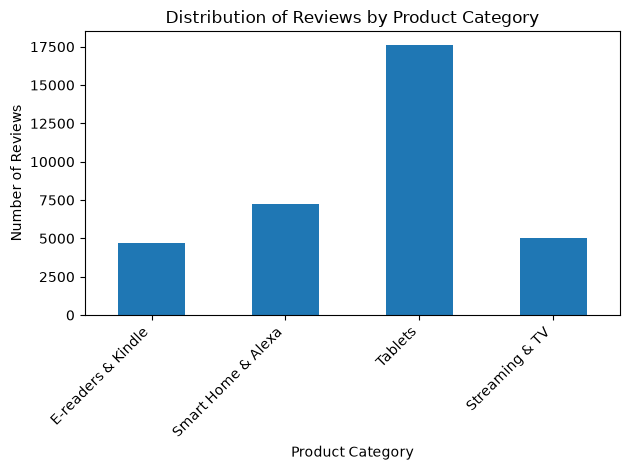

In [119]:
import matplotlib.pyplot as plt

cluster_counts = (
    df_cluster["category"]
    .value_counts()
    .reindex(category_names.values())
)

cluster_counts.plot(kind="bar")

plt.title("Distribution of Reviews by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [120]:
# Objective

The goal was to group the 34,626 reviews into 4–6 meaningful product meta-categories using unsupervised clustering.

Method
Combined name, categories, reviews.title and reviews.text into one text field.
Converted the text into numerical features using TF-IDF with 5,000 features.
Tested K-Means with 4, 5 and 6 clusters.
Compared the solutions using the Silhouette Score.
Clusters	Silhouette Score
4	0.2024
5	0.1979
6	0.1963

The 4-cluster solution was selected because it achieved the highest score and provided the most interpretable grouping.

Final Meta-Categories
Cluster	Meta-category	Main keywords / topics
0	E-readers & Kindle	Kindle, Paperwhite, ebook, readers, books
1	Smart Home & Alexa	Echo, Alexa, smart home, speakers, automation
2	Tablets	Fire Tablet, Fire HD, tablet, display, Android, apps
3	Streaming & TV	Fire TV, streaming, movies, TV, media, video

The categories were assigned by analyzing the dominant keywords, representative products and sample reviews within each cluster.

The clustering showed limited but interpretable separation, producing four useful meta-categories that will be used as the basis for Task 3 — Generative AI product-category summaries.

SyntaxError: invalid character '–' (U+2013) (778773903.py, line 3)

In [ ]:
# **TASK 3: Generate a summary for each product category using Generative AI**

In [121]:
df_cluster["product"] = df_cluster["name"].fillna(
    df_cluster["categories"]
)

print("Product column added.")

Product column added.


In [122]:
top_products = (
    df_cluster.groupby(["category", "product"])
    .size()
    .reset_index(name="reviews")
    .sort_values(
        ["category", "reviews"],
        ascending=[True, False]
    )
    .groupby("category")
    .head(3)
)

top_products

,category,product,reviews
7,E-readers & Kindle,Amazon Kindle Paperwhite - eBook reader - 4 GB...,3012
21,E-readers & Kindle,"Kindle Voyage E-reader, 6 High-Resolution Disp...",579
0,E-readers & Kindle,"All-New Kindle E-reader - Black, 6 Glare-Free ...",209
34,Smart Home & Alexa,"Echo (White),,,\r\nEcho (White),,,",2898
28,Smart Home & Alexa,"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",2527
40,Smart Home & Alexa,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",671
42,Streaming & TV,"Back To College,College Electronics,College Tv...",5056
70,Tablets,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",10753
43,Tablets,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",2814
68,Tablets,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",1685


In [123]:
top_products.groupby("category").size()

category
E-readers & Kindle    3
Smart Home & Alexa    3
Streaming & TV        1
Tablets               3
dtype: int64

In [124]:
df_cluster[
    df_cluster["category"] == "Streaming & TV"
][["reviews.title", "reviews.text"]].head(10)

,reviews.title,reviews.text
29573,Better Than Amazon Fire Stick,The Amazon Fire TV works better and faster tha...
29574,It a good product,I like the product and would tell others about...
29575,Good product,"Really like the voice commands, including comm..."
29576,Amazing product,Got it so I can have everything in one device ...
29577,Easy to use,Like the voice command option to search for sh...
29578,"Decent, but have to reset monthly","Decent, but have to reset monthly, i have to u..."
29579,Great equipment,Great purchase and good investment.Also wonder...
29580,great item to jailbreak,Follow the instruction on youtube and you can ...
29581,Works great,"Works as described, happy with the purchase.go..."
29582,Great Streaming device,Works exactly as I hoped and have had no issue...


In [125]:
df_cluster["reviews.rating"] = df_project_clean.loc[
    df_cluster.index,
    "reviews.rating"
]

In [126]:
df_cluster[
    ["category", "reviews.title", "reviews.text", "reviews.rating"]
].head()

,category,reviews.title,reviews.text,reviews.rating
0,Tablets,Kindle,This product so far has not disappointed. My c...,5.0
1,Tablets,very fast,great for beginner or experienced person. Boug...,5.0
2,Tablets,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,5.0
3,Tablets,Good!!!,I've had my Fire HD 8 two weeks now and I love...,4.0
4,Tablets,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,5.0


In [127]:
df_cluster.groupby("category")["reviews.rating"].count()

category
E-readers & Kindle     4685
Smart Home & Alexa     7262
Streaming & TV         5056
Tablets               17623
Name: reviews.rating, dtype: int64

In [128]:
df_cluster.info()

<class 'pandas.DataFrame'>
Index: 34626 entries, 0 to 34659
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            27867 non-null  str    
 1   brand           34626 non-null  str    
 2   categories      34626 non-null  str    
 3   reviews.title   34620 non-null  str    
 4   reviews.text    34626 non-null  str    
 5   combined_text   34626 non-null  str    
 6   cluster         34626 non-null  int32  
 7   category        34626 non-null  str    
 8   product         34626 non-null  str    
 9   reviews.rating  34626 non-null  float64
dtypes: float64(1), int32(1), str(8)
memory usage: 43.5 MB


In [129]:
top_products = (
    df_cluster.groupby(["category", "product"])
    .agg(
        reviews=("product", "size"),
        rating=("reviews.rating", "mean")
    )
    .reset_index()
    .sort_values(
        ["category", "reviews"],
        ascending=[True, False]
    )
    .groupby("category")
    .head(3)
)

top_products["rating"] = top_products["rating"].round(2)

top_products

,category,product,reviews,rating
7,E-readers & Kindle,Amazon Kindle Paperwhite - eBook reader - 4 GB...,3012,4.77
21,E-readers & Kindle,"Kindle Voyage E-reader, 6 High-Resolution Disp...",579,4.74
0,E-readers & Kindle,"All-New Kindle E-reader - Black, 6 Glare-Free ...",209,4.44
34,Smart Home & Alexa,"Echo (White),,,\r\nEcho (White),,,",2898,4.68
28,Smart Home & Alexa,"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",2527,4.65
40,Smart Home & Alexa,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",671,4.67
42,Streaming & TV,"Back To College,College Electronics,College Tv...",5056,4.71
70,Tablets,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",10753,4.45
43,Tablets,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",2814,4.59
68,Tablets,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",1685,4.51


In [130]:
category_rating = (
    df_cluster
    .groupby("category")["reviews.rating"]
    .agg(["mean", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
)

category_rating

,mean,count
category,,
E-readers & Kindle,4.71,4685
Streaming & TV,4.71,5056
Smart Home & Alexa,4.66,7262
Tablets,4.48,17623


In [131]:
top_products = (
    df_cluster
    .groupby(["category", "product"])
    .agg(
        reviews=("product", "size"),
        rating=("reviews.rating", "mean")
    )
    .reset_index()
    .sort_values(
        ["category", "reviews"],
        ascending=[True, False]
    )
    .groupby("category")
    .head(3)
)

top_products["rating"] = top_products["rating"].round(2)

top_products

,category,product,reviews,rating
7,E-readers & Kindle,Amazon Kindle Paperwhite - eBook reader - 4 GB...,3012,4.77
21,E-readers & Kindle,"Kindle Voyage E-reader, 6 High-Resolution Disp...",579,4.74
0,E-readers & Kindle,"All-New Kindle E-reader - Black, 6 Glare-Free ...",209,4.44
34,Smart Home & Alexa,"Echo (White),,,\r\nEcho (White),,,",2898,4.68
28,Smart Home & Alexa,"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",2527,4.65
40,Smart Home & Alexa,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",671,4.67
42,Streaming & TV,"Back To College,College Electronics,College Tv...",5056,4.71
70,Tablets,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",10753,4.45
43,Tablets,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",2814,4.59
68,Tablets,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",1685,4.51


In [132]:
tablets_reviews = df_cluster[
    df_cluster["category"] == "Tablets"
][["product", "reviews.title", "reviews.text", "reviews.rating"]]

tablets_reviews.head(20)

,product,reviews.title,reviews.text,reviews.rating
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Kindle,This product so far has not disappointed. My c...,5.0
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",very fast,great for beginner or experienced person. Boug...,5.0
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,5.0
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Good!!!,I've had my Fire HD 8 two weeks now and I love...,4.0
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Fantastic Tablet for kids,I bought this for my grand daughter when she c...,5.0
5,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Just what we expected,This amazon fire 8 inch tablet is the perfect ...,5.0
6,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",great e-reader tablet,"Great for e-reading on the go, nice and light ...",4.0
7,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Great for gifts,"I gave this as a Christmas gift to my inlaws, ...",5.0
8,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Great for reading,Great as a device to read books. I like that i...,5.0
9,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Great and lightweight reader,I love ordering books and reading them with th...,5.0


In [133]:
from sklearn.feature_extraction.text import TfidfVectorizer

tablets_text = (
    tablets_reviews["reviews.title"].fillna("") + " " +
    tablets_reviews["reviews.text"].fillna("")
)

tablets_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000,
    ngram_range=(1, 2)
)

tablets_tfidf = tablets_vectorizer.fit_transform(tablets_text)

print("Number of reviews:", tablets_tfidf.shape[0])
print("Number of features:", tablets_tfidf.shape[1])

Number of reviews: 17623
Number of features: 1000


In [134]:
import pandas as pd

feature_names = tablets_vectorizer.get_feature_names_out()

tfidf_scores = tablets_tfidf.mean(axis=0).A1

top_terms = (
    pd.DataFrame({
        "term": feature_names,
        "score": tfidf_scores
    })
    .sort_values("score", ascending=False)
    .head(30)
)

top_terms

,term,score
837,tablet,0.073934
369,great,0.073513
338,good,0.041423
671,price,0.039880
522,love,0.034667
919,use,0.034274
455,kids,0.033734
396,great tablet,0.032036
236,easy,0.030270
104,bought,0.029455


In [135]:
tablets_positive = tablets_reviews[
    tablets_reviews["reviews.rating"] >= 4
].copy()

tablets_negative = tablets_reviews[
    tablets_reviews["reviews.rating"] <= 2
].copy()

print("Positive reviews:", len(tablets_positive))
print("Negative reviews:", len(tablets_negative))

Positive reviews: 16105
Negative reviews: 532


In [136]:
negative_text = (
    tablets_negative["reviews.title"].fillna("") + " " +
    tablets_negative["reviews.text"].fillna("")
)

negative_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=500,
    ngram_range=(1, 2)
)

negative_tfidf = negative_vectorizer.fit_transform(negative_text)

negative_features = negative_vectorizer.get_feature_names_out()

negative_scores = negative_tfidf.mean(axis=0).A1

negative_terms = (
    pd.DataFrame({
        "term": negative_features,
        "score": negative_scores
    })
    .sort_values("score", ascending=False)
    .head(30)
)

negative_terms

,term,score
413,tablet,0.066801
16,amazon,0.047129
183,good,0.039523
381,slow,0.035374
26,apps,0.033967
47,bought,0.031532
450,use,0.030516
229,kindle,0.030014
237,like,0.028992
53,buy,0.028117


In [137]:
# Create positive and negative TF-IDF score tables

positive_scores_df = pd.DataFrame({
    "term": positive_features,
    "positive_score": positive_scores
})

negative_scores_df = pd.DataFrame({
    "term": negative_features,
    "negative_score": negative_scores
})

# Merge positive and negative scores
keyword_comparison = positive_scores_df.merge(
    negative_scores_df,
    on="term",
    how="outer"
).fillna(0)

# Keep only words that are clearly more characteristic
# of one sentiment than the other

positive_keywords = keyword_comparison[
    keyword_comparison["positive_score"] >
    keyword_comparison["negative_score"] * 1.5
].sort_values(
    "positive_score",
    ascending=False
).head(30)

negative_keywords = keyword_comparison[
    keyword_comparison["negative_score"] >
    keyword_comparison["positive_score"] * 1.5
].sort_values(
    "negative_score",
    ascending=False
).head(30)

print("POSITIVE KEYWORDS")
display(
    positive_keywords[["term", "positive_score"]]
)

print("NEGATIVE KEYWORDS")
display(
    negative_keywords[["term", "negative_score"]]
)

NameError: name 'positive_features' is not defined

In [138]:
positive_themes = {
    "Value for money": [
        "price", "great price", "value"
    ],
    "Ease of use": [
        "easy", "easy use"
    ],
    "Children": [
        "kids", "year old", "son", "daughter"
    ],
    "Reading": [
        "reading"
    ],
    "Gift": [
        "gift", "christmas"
    ]
}

negative_themes = {
    "Performance": [
        "slow"
    ],
    "Battery and charging": [
        "charge", "charging", "charger"
    ],
    "Apps and software": [
        "apps", "app", "download"
    ],
    "Screen": [
        "screen"
    ],
    "Advertising": [
        "ads"
    ],
    "Connectivity": [
        "wifi", "internet"
    ],
    "Reliability": [
        "returned", "disappointed"
    ]
}

print("POSITIVE THEMES")
for theme, keywords in positive_themes.items():
    print(f"- {theme}: {', '.join(keywords)}")

print("\nNEGATIVE THEMES")
for theme, keywords in negative_themes.items():
    print(f"- {theme}: {', '.join(keywords)}")

POSITIVE THEMES
- Value for money: price, great price, value
- Ease of use: easy, easy use
- Children: kids, year old, son, daughter
- Reading: reading
- Gift: gift, christmas

NEGATIVE THEMES
- Performance: slow
- Battery and charging: charge, charging, charger
- Apps and software: apps, app, download
- Screen: screen
- Advertising: ads
- Connectivity: wifi, internet
- Reliability: returned, disappointed


In [139]:
theme_results = []

all_themes = {
    **positive_themes,
    **negative_themes
}

for theme, keywords in all_themes.items():

    pattern = "|".join(keywords)

    mask = (
        tablets_reviews["reviews.title"].fillna("").str.contains(
            pattern, case=False, na=False
        )
        |
        tablets_reviews["reviews.text"].fillna("").str.contains(
            pattern, case=False, na=False
        )
    )

    matched_reviews = tablets_reviews[mask]

    theme_results.append({
        "theme": theme,
        "reviews": len(matched_reviews),
        "avg_rating": round(
            matched_reviews["reviews.rating"].mean(), 2
        )
    })

theme_results = pd.DataFrame(theme_results)

theme_results = theme_results.sort_values(
    "avg_rating",
    ascending=False
)

theme_results

,theme,reviews,avg_rating
1,Ease of use,2900,4.65
4,Gift,2402,4.61
3,Reading,1236,4.54
2,Children,6105,4.53
0,Value for money,4914,4.51
7,Apps and software,3522,4.32
8,Screen,1322,4.32
10,Connectivity,725,4.25
9,Advertising,424,4.19
6,Battery and charging,523,3.94


In [140]:
import os

os.environ["HF_HUB_DISABLE_XET"] = "1"

print("Xet disabled.")

Xet disabled.


In [ ]:
# INTERMEDIATE FEEDBACK ON TASK 3

Several pretrained generative models were tested to identify a suitable solution for automatically summarizing customer reviews.
First, Google FLAN-T5-small was tested, but its outputs were too short and generic to provide useful summaries.
Google FLAN-T5-base produced more meaningful initial results, but the quality decreased for longer inputs and it sometimes mixed positive and negative feedback.
We then tested BART-large-CNN, a model specifically designed for text summarization. However, its size made local installation and execution impractical on the available CPU-based hardware.
As a final attempt before moving to an external LLM API, we are testing DistilBART-CNN-6-6, a smaller distilled version of BART designed for summarization.
The objective is to find a model that can generate concise, coherent and faithful summaries while remaining feasible to run locally.

In [141]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

distilbart_model_name = "sshleifer/distilbart-cnn-6-6"

distilbart_tokenizer = AutoTokenizer.from_pretrained(
    distilbart_model_name
)

distilbart_model = AutoModelForSeq2SeqLM.from_pretrained(
    distilbart_model_name
)

print("DistilBART-CNN-6-6 loaded successfully.")

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100%|██████████| 262/262 [00:00<00:00, 14633.57it/s]

DistilBART-CNN-6-6 loaded successfully.


In [142]:
tablet_data_8 = []

for _, row in top_products[
    top_products["category"] == "Tablets"
].head(1).iterrows():

    product = row["product"]

    product_reviews = df_cluster[
        (df_cluster["category"] == "Tablets") &
        (df_cluster["product"] == product)
    ].copy()

    positive_reviews = product_reviews[
        product_reviews["reviews.rating"] >= 4
    ]

    negative_reviews = product_reviews[
        product_reviews["reviews.rating"] <= 2
    ]

    tablet_data_8.append({
        "product": product,
        "review_count": len(product_reviews),
        "average_rating": round(
            product_reviews["reviews.rating"].mean(), 2
        ),
        "positive_reviews": positive_reviews.sample(
            n=min(8, len(positive_reviews)),
            random_state=42
        )["reviews.text"].tolist(),
        "negative_reviews": negative_reviews.sample(
            n=min(8, len(negative_reviews)),
            random_state=42
        )["reviews.text"].tolist()
    })

print("Product:", tablet_data_8[0]["product"])
print("Reviews:", tablet_data_8[0]["review_count"])
print("Rating:", tablet_data_8[0]["average_rating"])
print("Positive samples:", len(tablet_data_8[0]["positive_reviews"]))
print("Negative samples:", len(tablet_data_8[0]["negative_reviews"]))

Product: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta
Reviews: 10753
Rating: 4.45
Positive samples: 8
Negative samples: 8


In [143]:
item = tablet_data_8[0]

product_text = (
    "Customer reviews about this product:\n\n"
    "Positive reviews:\n" +
    "\n".join(item["positive_reviews"]) +
    "\n\nNegative reviews:\n" +
    "\n".join(item["negative_reviews"])
)

inputs = distilbart_tokenizer(
    product_text,
    return_tensors="pt",
    truncation=True,
    max_length=1024
)

outputs = distilbart_model.generate(
    **inputs,
    max_new_tokens=150,
    num_beams=4
)

product_summary = distilbart_tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print("Product summary:\n")
print(product_summary)

[transformers] Both `max_new_tokens` (=150) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Product summary:

 The tablet is nothing like the reviews said. It FREEZES up every time I press "Home" or go to the next page or even to close out . When I go on the internet, some pages do not load fully. 9/10 times only the 1st half of the page was loaded .


In [144]:
item = tablet_data_8[0]

positive_text = "\n".join(item["positive_reviews"])

inputs = distilbart_tokenizer(
    positive_text,
    return_tensors="pt",
    truncation=True,
    max_length=1024
)

outputs = distilbart_model.generate(
    **inputs,
    max_new_tokens=120,
    num_beams=4
)

positive_summary = distilbart_tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print("Positive summary:\n")
print(positive_summary)

[transformers] Both `max_new_tokens` (=120) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Positive summary:

 The ereader is more like a tablet or iPad but without the huge price . It's a great purchase for my daughters elderly friend across the street . Love the child profiles for my kids and all the parental controls! Great for priceGot it on sale for $34.99.


In [ ]:
negative_text = "\n".join(item["negative_reviews"])

inputs = distilbart_tokenizer(
    negative_text,
    return_tensors="pt",
    truncation=True,
    max_length=1024
)

outputs = distilbart_model.generate(
    **inputs,
    max_new_tokens=120,
    num_beams=4
)

negative_summary = distilbart_tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print("Negative summary:\n")
print(negative_summary)

[transformers] Both `max_new_tokens` (=120) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Negative summary:

 The tablet is nothing like the reviews said. It FREEZES up every time I press "Home" or go to the next page or even to close out . When I go on the internet, some pages do not load fully . It doesn't play all of my favorite games from the App Store, nor does it sync


In [ ]:
# FEEDBACK FROM DISTILBART-CNN-6-6 :

DistilBART-CNN-6-6 was tested as a lightweight local summarization model. 
Although it was able to identify relevant information from customer reviews, its outputs were often too close to individual source reviews and did not consistently synthesize multiple reviews. 
Therefore, an external LLM API was considered more suitable for the final category-level article generation.

In [145]:
import sys

print(sys.executable)

c:\Users\sandv\OneDrive\Plocha\IVAN\IRON HACK\.ipynb dal corso\w4\venv\Scripts\python.exe


In [146]:
import sys
!{sys.executable} -m pip install -U google-genai

'c:\Users\sandv\OneDrive\Plocha\IVAN\IRON' is not recognized as an internal or external command,
operable program or batch file.


In [147]:
import sys
print(sys.executable)

c:\Users\sandv\OneDrive\Plocha\IVAN\IRON HACK\.ipynb dal corso\w4\venv\Scripts\python.exe


In [148]:
import subprocess
import sys

subprocess.run([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-U",
    "google-genai"
])

CompletedProcess(args=['c:\\Users\\sandv\\OneDrive\\Plocha\\IVAN\\IRON HACK\\.ipynb dal corso\\w4\\venv\\Scripts\\python.exe', '-m', 'pip', 'install', '-U', 'google-genai'], returncode=0)

In [149]:
from google import genai

print("google-genai OK")

google-genai OK


In [158]:
from google import genai
import os

client = genai.Client(
    api_key=os.environ.get("GEMINI_API_KEY")
)

response = client.models.generate_content(
    model="gemini-3.8-flash",
    contents="hello, world?"
)

print(response.text)

Hello! 👋 System is running and ready. 

How can I help you today?


In [159]:
from dotenv import load_dotenv
import os

load_dotenv()

if os.getenv("GEMINI_API_KEY"):
    print("API key caricata correttamente")
else:
    print("API key NON trovata")

API key caricata correttamente


In [168]:
from google import genai
import os

# Gemini client
client = genai.Client(
    api_key=os.environ.get("GEMINI_API_KEY")
)

# Select the first Tablets product
item = tablet_data_8[0]

product_name = item["product"]
average_rating = item["average_rating"]
review_count = item["review_count"]

positive_reviews = item["positive_reviews"]
negative_reviews = item["negative_reviews"]

# Build the prompt
prompt = f"""
You are a professional product reviewer.

Write a concise and objective customer-review summary of the following tablet.

PRODUCT:
{product_name}

AVERAGE RATING:
{average_rating}/5

NUMBER OF REVIEWS:
{review_count}

POSITIVE CUSTOMER FEEDBACK:
"""

for review in positive_reviews:
    prompt += f"- {review}\n"

prompt += """

NEGATIVE CUSTOMER FEEDBACK:
"""

for review in negative_reviews:
    prompt += f"- {review}\n"

prompt += """

TASK:

Write a short product review of approximately 150-200 words.

The review must:
- summarize the main strengths mentioned by customers;
- summarize the main weaknesses mentioned by customers;
- explain who this tablet seems suitable for;
- mention the most important recurring complaints;
- give an overall balanced recommendation.

IMPORTANT:
- Do not copy customer reviews verbatim.
- Do not invent specifications, features or problems that are not present in the feedback.
- Do not mention individual reviewers.
- Do not simply list the reviews.
- Synthesize the information across the reviews.
- Base the review only on the information provided above.
"""

# Generate the review
response = client.models.generate_content(
    model="gemini-3.8-flash",
    contents=prompt
)

# Print result
print("=" * 80)
print(product_name)
print("=" * 80)
print()
print(response.text)

Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta

The Fire 7 Tablet stands out primarily for its exceptional value, making it an appealing, low-cost option for basic digital entertainment. Customers consistently praise its affordability, effortless setup, and user-friendly navigation. Featuring dedicated parental controls and child profiles, as well as support for streaming platforms like Netflix and Amazon Prime, this tablet is particularly well-suited for young children, seniors, and casual users seeking an inexpensive media device.

However, the budget price point entails clear performance trade-offs. The most critical recurring complaints center on sluggish responsiveness, with frequent reports of the screen freezing, touch commands failing to register, and web pages loading incompletely. Additionally, customers highlight the constraints of the 8 GB storage capacity, a modest battery life of roughly seven hours, display glitches such as green tinting, and soft

In [169]:
tablet_data_8 = []

# Get the top 3 Tablets products
top_tablets = top_products[
    top_products["category"] == "Tablets"
].head(3)

for _, row in top_tablets.iterrows():

    product = row["product"]

    product_reviews = df_cluster[
        (df_cluster["category"] == "Tablets") &
        (df_cluster["product"] == product)
    ].copy()

    positive_reviews = product_reviews[
        product_reviews["reviews.rating"] >= 4
    ]

    negative_reviews = product_reviews[
        product_reviews["reviews.rating"] <= 2
    ]

    tablet_data_8.append({
        "product": product,
        "review_count": len(product_reviews),
        "average_rating": round(
            product_reviews["reviews.rating"].mean(), 2
        ),
        "positive_reviews": positive_reviews.sample(
            n=min(8, len(positive_reviews)),
            random_state=42
        )["reviews.text"].tolist(),
        "negative_reviews": negative_reviews.sample(
            n=min(8, len(negative_reviews)),
            random_state=42
        )["reviews.text"].tolist()
    })

print("Products prepared:", len(tablet_data_8))

for i, item in enumerate(tablet_data_8, start=1):
    print(f"\n{i}. {item['product']}")
    print("Reviews:", item["review_count"])
    print("Average rating:", item["average_rating"])
    print("Positive samples:", len(item["positive_reviews"]))
    print("Negative samples:", len(item["negative_reviews"]))

Products prepared: 3

1. Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta
Reviews: 10753
Average rating: 4.45
Positive samples: 8
Negative samples: 8

2. All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
Reviews: 2814
Average rating: 4.59
Positive samples: 8
Negative samples: 8

3. Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case
Reviews: 1685
Average rating: 4.51
Positive samples: 8
Negative samples: 8


In [ ]:
item = tablet_data_8[1]

product_name = item["product"]
average_rating = item["average_rating"]
review_count = item["review_count"]

prompt = f"""
You are a professional product reviewer.

Write a concise and objective customer-review summary of this tablet.

PRODUCT:
{product_name}

AVERAGE RATING:
{average_rating}/5

NUMBER OF REVIEWS:
{review_count}

POSITIVE CUSTOMER FEEDBACK:
"""

for review in item["positive_reviews"]:
    prompt += f"- {review}\n"

prompt += """

NEGATIVE CUSTOMER FEEDBACK:
"""

for review in item["negative_reviews"]:
    prompt += f"- {review}\n"

prompt += """

TASK:

Write a short product review of approximately 150-200 words.

The review must:
- summarize the main strengths mentioned by customers;
- summarize the main weaknesses mentioned by customers;
- explain who this tablet seems suitable for;
- mention the most important recurring complaints;
- give an overall balanced recommendation.

IMPORTANT:
- Do not copy customer reviews verbatim.
- Do not invent specifications, features or problems.
- Do not mention individual reviewers.
- Do not simply list the reviews.
- Synthesize the information across the reviews.
- Only report information supported by the customer feedback.
"""

response = client.models.generate_content(
    model="gemini-3.7-flash",
    contents=prompt
)

print("=" * 80)
print(product_name)
print("=" * 80)
print()
print(response.text)

All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta

With an impressive 4.59 out of 5 rating from over 2,800 reviews, the Fire HD 8 is praised as an affordable alternative to premium devices. Customers highlight its clear HD display, dependable battery life, and expandable SD card storage, making it well-received for reading, video streaming, and light gaming.

However, several recurring weaknesses temper user satisfaction. Performance bottlenecks are common, with reports of sluggish loading, video buffering, and slow screen rotation. Users also express frustration over bloatware, noting that pre-installed Amazon apps cannot be removed. More critically, notable hardware and connectivity defects—specifically charging failures, dropped Wi-Fi connections, and unexpected shutdowns—are frequent complaints.

This tablet is best suited for budget-conscious buyers, seniors, and children seeking an economical device for casual travel entertainment and basic m

In [194]:
from google import genai
import os

# Gemini client
client = genai.Client(
    api_key=os.environ.get("GEMINI_API_KEY")
)

# Select the third Tablets product
item = tablet_data_8[2]

product_name = item["product"]
average_rating = item["average_rating"]
review_count = item["review_count"]

positive_reviews = item["positive_reviews"]
negative_reviews = item["negative_reviews"]

# Build the prompt
prompt = f"""
You are a professional product reviewer.

Write a concise and objective customer-review summary of this tablet.

PRODUCT:
{product_name}

AVERAGE RATING:
{average_rating}/5

NUMBER OF REVIEWS:
{review_count}

POSITIVE CUSTOMER FEEDBACK:
"""

for review in positive_reviews:
    prompt += f"- {review}\n"

prompt += """

NEGATIVE CUSTOMER FEEDBACK:
"""

for review in negative_reviews:
    prompt += f"- {review}\n"

prompt += """

TASK:

Write a short product review of approximately 150-200 words.

The review must:
- summarize the main strengths mentioned by customers;
- summarize the main weaknesses mentioned by customers;
- explain who this tablet seems suitable for;
- mention the most important recurring complaints;
- give an overall balanced recommendation.

IMPORTANT:
- Do not copy customer reviews verbatim.
- Do not invent specifications, features or problems.
- Do not mention individual reviewers.
- Do not simply list the reviews.
- Synthesize the information across the reviews.
- Only report information supported by the customer feedback.
- Do not present a single customer's experience as a general product characteristic.
- Avoid overly precise technical claims unless they are clearly supported by multiple reviews.
"""

# Generate the review
response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

# Print result
print("=" * 80)
print(product_name)
print("=" * 80)
print()
print(response.text)

Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case

Boasting a strong 4.51 out of 5-star rating across over 1,600 reviews, the Fire Kids Edition Tablet is widely regarded as a practical, durable device for toddlers, young children, and kids with special needs. Its primary strengths lie in its protective kid-proof case, reliable warranty, robust parental controls for monitoring usage, and a vast library of pre-loaded educational content.

However, customer feedback reveals several notable weaknesses and recurring complaints. Performance can be sluggish, with slow app loading times and web browsing. Users also express frustration over app restrictions—specifically the lack of access to the Google Play Store—and mandatory registration within the Amazon ecosystem. Most concerningly, a recurring hardware issue involves fragile charging ports that fail, stop holding cables securely, or prevent the device from charging altogether.

**Verdict:**
This tablet is best suited 

In [195]:
# Store the three generated product reviews

fire7_review = """================================================================================
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta
================================================================================

The Fire 7 Tablet stands out primarily for its exceptional value, making it an appealing, low-cost option for basic digital entertainment. Customers consistently praise its affordability, effortless setup, and user-friendly navigation. Featuring dedicated parental controls and child profiles, as well as support for streaming platforms like Netflix and Amazon Prime, this tablet is particularly well-suited for young children, seniors, and casual users seeking an inexpensive media device.

However, the budget price point entails clear performance trade-offs. The most critical recurring complaints center on sluggish responsiveness, with frequent reports of the screen freezing, touch commands failing to register, and web pages loading incompletely. Additionally, customers highlight the constraints of the 8 GB storage capacity, a modest battery life of roughly seven hours, display glitches such as green tinting, and software restrictions that limit app availability and peripheral compatibility.

Overall, the Fire 7 is recommended as a practical, wallet-friendly purchase for light reading, basic video watching, or as a starter tablet for kids. However, buyers needing swift multitasking, extensive storage, or the full capabilities of standard app ecosystems should invest in a more robust device."""

fire_hd8_review = """================================================================================
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
================================================================================

With an impressive 4.59 out of 5 rating from over 2,800 reviews, the Fire HD 8 is praised as an affordable alternative to premium devices. Customers highlight its clear HD display, dependable battery life, and expandable SD card storage, making it well-received for reading, video streaming, and light gaming.

However, several recurring weaknesses temper user satisfaction. Performance bottlenecks are common, with reports of sluggish loading, video buffering, and slow screen rotation. Users also express frustration over bloatware, noting that pre-installed Amazon apps cannot be removed. More critically, notable hardware and connectivity defects—specifically charging failures, dropped Wi-Fi connections, and unexpected shutdowns—are frequent complaints.

This tablet is best suited for budget-conscious buyers, seniors, and children seeking an economical device for casual travel entertainment and basic media consumption. It is not recommended for power users who demand the swift multitasking or polished software experience of higher-end tablets like an iPad or Samsung Galaxy Tab. 

Overall, the Fire HD 8 offers solid value for everyday basic tasks, provided buyers are willing to accept modest processing speeds and potential reliability issues."""

fire_kids_review = """================================================================================
Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case
================================================================================

Boasting a strong 4.51 out of 5-star rating across over 1,600 reviews, the Fire Kids Edition Tablet is widely regarded as a practical, durable device for toddlers, young children, and kids with special needs. Its primary strengths lie in its protective kid-proof case, reliable warranty, robust parental controls for monitoring usage, and a vast library of pre-loaded educational content.

However, customer feedback reveals several notable weaknesses and recurring complaints. Performance can be sluggish, with slow app loading times and web browsing. Users also express frustration over app restrictions—specifically the lack of access to the Google Play Store—and mandatory registration within the Amazon ecosystem. Most concerningly, a recurring hardware issue involves fragile charging ports that fail, stop holding cables securely, or prevent the device from charging altogether.

**Verdict:**
This tablet is best suited for parents seeking an affordable, drop-resistant media tool with strong built-in safety controls for young children. Overall, it offers a balanced, budget-friendly option for early learning and entertainment, provided buyers are comfortable with Amazon's locked-in software ecosystem and modest processing speeds."""

print("Three product reviews saved successfully.")

Three product reviews saved successfully.


In [203]:
from google import genai
import os

client = genai.Client(
    api_key=os.environ.get("GEMINI_API_KEY")
)

comparison_prompt = f"""
You are a professional technology reviewer.

Write a short recommendation article comparing the three Amazon Fire tablets below.

PRODUCT 1:
Fire Tablet 7
Average rating: 4.45/5
Number of reviews: 10753

CUSTOMER REVIEW SUMMARY:
{fire7_review}

PRODUCT 2:
All-New Fire HD 8 Tablet
Average rating: 4.59/5
Number of reviews: 2814

CUSTOMER REVIEW SUMMARY:
{fire_hd8_review}

PRODUCT 3:
Fire Kids Edition Tablet
Average rating: 4.51/5
Number of reviews: 1685

CUSTOMER REVIEW SUMMARY:
{fire_kids_review}

TASK:

Write a concise recommendation article of approximately 500-700 words.

The article should:

1. Introduce the three tablets and explain the main differences between them.
2. Compare their main strengths.
3. Compare their main weaknesses and recurring customer complaints.
4. Explain which tablet is best for:
   - children and families;
   - general everyday use;
   - buyers looking for the best value for money.
5. Identify the main trade-offs between the three products.
6. Clearly state which tablet you would recommend for each type of buyer.
7. Finish with a concise overall recommendation.

IMPORTANT:

- Base the article only on the information provided above.
- Do not invent specifications or features.
- Do not copy the product summaries verbatim.
- Do not mention individual reviewers.
- Do not simply repeat the three summaries one after another.
- The article must compare the products directly.
- Clearly distinguish strengths from weaknesses.
- Use an objective and balanced tone.
- The article should read like a genuine technology recommendation article.
"""

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=comparison_prompt
)

print("=" * 80)
print("TABLETS — FINAL CATEGORY ARTICLE")
print("=" * 80)
print()
print(response.text)

TABLETS — FINAL CATEGORY ARTICLE

# Finding the Right Fit: Amazon Fire 7 vs. Fire HD 8 vs. Fire Kids Edition

Amazon’s Fire tablet lineup is highly regarded for delivering accessible, budget-friendly digital entertainment. However, choosing between the ultra-affordable Fire 7, the upgraded Fire HD 8, and the durable Fire Kids Edition requires looking closely at their distinct designs and target audiences. While the Fire 7 and Kids Edition both sport 7-inch displays, the Kids Edition adds a rugged protective case and kid-friendly software. Meanwhile, the Fire HD 8 steps up the screen real estate to an 8-inch high-definition display and doubles the base storage of the standard Fire 7. 

Here is how these three devices compare in real-world performance, strengths, weaknesses, and overall value.

---

### The Strengths: Where Each Tablet Shines

Each device brings clear advantages to the table depending on your primary use case:

*   **Fire Tablet 7:** This model shines as a remarkably ine

In [204]:
# Select the top 3 products for a category

category = "E-readers & Kindle"

top_category_products = (
    top_products[
        top_products["category"] == category
    ]
    .head(3)
)

display(top_category_products)

,category,product,reviews,rating
7,E-readers & Kindle,Amazon Kindle Paperwhite - eBook reader - 4 GB...,3012,4.77
21,E-readers & Kindle,"Kindle Voyage E-reader, 6 High-Resolution Disp...",579,4.74
0,E-readers & Kindle,"All-New Kindle E-reader - Black, 6 Glare-Free ...",209,4.44


In [205]:
# Collect positive and negative review samples for the top 3 products

ereader_data_8 = []

top_ereaders = top_products[
    top_products["category"] == "E-readers & Kindle"
].head(3)

for _, row in top_ereaders.iterrows():

    product = row["product"]

    product_reviews = df_cluster[
        (df_cluster["category"] == "E-readers & Kindle") &
        (df_cluster["product"] == product)
    ].copy()

    positive_reviews = product_reviews[
        product_reviews["reviews.rating"] >= 4
    ]

    negative_reviews = product_reviews[
        product_reviews["reviews.rating"] <= 2
    ]

    ereader_data_8.append({
        "product": product,
        "review_count": len(product_reviews),
        "average_rating": round(
            product_reviews["reviews.rating"].mean(), 2
        ),
        "positive_reviews": positive_reviews.sample(
            n=min(8, len(positive_reviews)),
            random_state=42
        )["reviews.text"].tolist(),
        "negative_reviews": negative_reviews.sample(
            n=min(8, len(negative_reviews)),
            random_state=42
        )["reviews.text"].tolist()
    })

print("E-reader data prepared:")
for item in ereader_data_8:
    print(
        item["product"],
        "|",
        item["review_count"],
        "reviews |",
        item["average_rating"],
        "| +",
        len(item["positive_reviews"]),
        "| -",
        len(item["negative_reviews"])
    )

E-reader data prepared:
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,, | 3012 reviews | 4.77 | + 8 | - 8
Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers, | 579 reviews | 4.74 | + 8 | - 4
All-New Kindle E-reader - Black, 6 Glare-Free Touchscreen Display, Wi-Fi -  Includes Special Offers,, | 209 reviews | 4.44 | + 8 | - 8


In [213]:
# Generate the E-readers & Kindle category article with Gemini

ereader_prompt = """
You are a professional technology reviewer.

Write a short recommendation article comparing the three Kindle products below.

PRODUCT 1:
{product1}

Average rating: {rating1}/5
Number of reviews: {reviews1}

Positive customer reviews:
{positive1}

Negative customer reviews:
{negative1}

PRODUCT 2:
{product2}

Average rating: {rating2}/5
Number of reviews: {reviews2}

Positive customer reviews:
{positive2}

Negative customer reviews:
{negative2}

PRODUCT 3:
{product3}

Average rating: {rating3}/5
Number of reviews: {reviews3}

Positive customer reviews:
{positive3}

Negative customer reviews:
{negative3}

TASK:

Write a concise recommendation article of approximately 500-700 words.

The article should:

1. Introduce the three Kindle products and explain their main differences.
2. Compare their main strengths based on customer feedback.
3. Compare their main weaknesses and recurring complaints.
4. Explain which product is best for different types of readers.
5. Identify the main trade-offs between the three products.
6. Clearly state which product you would recommend for each type of buyer.
7. Finish with a concise overall recommendation.

IMPORTANT:

- Base the article only on the information provided above.
- Do not invent specifications, features, prices or technical details.
- Do not copy individual reviews verbatim.
- Do not mention individual reviewers.
- Do not simply repeat the three products one after another.
- The article must compare the products directly.
- Clearly distinguish strengths from weaknesses.
- Use an objective and balanced tone.
- The article should read like a genuine technology recommendation article.
"""

p1 = ereader_data_8[0]
p2 = ereader_data_8[1]
p3 = ereader_data_8[2]

ereader_prompt = ereader_prompt.format(
    product1=p1["product"],
    rating1=p1["average_rating"],
    reviews1=p1["review_count"],
    positive1="\n".join(p1["positive_reviews"]),
    negative1="\n".join(p1["negative_reviews"]),

    product2=p2["product"],
    rating2=p2["average_rating"],
    reviews2=p2["review_count"],
    positive2="\n".join(p2["positive_reviews"]),
    negative2="\n".join(p2["negative_reviews"]),

    product3=p3["product"],
    rating3=p3["average_rating"],
    reviews3=p3["review_count"],
    positive3="\n".join(p3["positive_reviews"]),
    negative3="\n".join(p3["negative_reviews"])
)

response_ereader = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=ereader_prompt
)

print(response_ereader.text)

Finding your perfect e-reader depends heavily on your budget and specific reading habits. Amazon’s Kindle lineup offers options tailored to different needs, but they vary significantly in display resolution, lighting, physical controls, and overall value. This article compares three popular models: the versatile **Kindle Paperwhite (4 GB)**, the premium **Kindle Voyage**, and the entry-level **All-New Kindle E-reader**. 

All three devices share a 6-inch screen size, glare-free reading capabilities, and Wi-Fi connectivity, but their targeted user experiences are quite distinct.

---

### Main Strengths: Where They Excel

The **Kindle Paperwhite** is highly praised by customers for its exceptional organizational features. Users can easily group books into custom folders and sort their library by author, title, or purchase date. Its built-in backlight and adjustable font sizes make it incredibly easy on the eyes. With a lightweight, water-resistant design and a long battery life, it is a

In [214]:
# Select the top 3 products for Smart Home & Alexa

category = "Smart Home & Alexa"

top_smart_home = (
    top_products[
        top_products["category"] == category
    ]
    .head(3)
)

display(top_smart_home)

,category,product,reviews,rating
34,Smart Home & Alexa,"Echo (White),,,\r\nEcho (White),,,",2898,4.68
28,Smart Home & Alexa,"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",2527,4.65
40,Smart Home & Alexa,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",671,4.67


In [215]:
# Collect positive and negative review samples for Smart Home & Alexa

smart_home_data_8 = []

top_smart_home = top_products[
    top_products["category"] == "Smart Home & Alexa"
].head(3)

for _, row in top_smart_home.iterrows():

    product = row["product"]

    product_reviews = df_cluster[
        (df_cluster["category"] == "Smart Home & Alexa") &
        (df_cluster["product"] == product)
    ].copy()

    positive_reviews = product_reviews[
        product_reviews["reviews.rating"] >= 4
    ]

    negative_reviews = product_reviews[
        product_reviews["reviews.rating"] <= 2
    ]

    smart_home_data_8.append({
        "product": product,
        "review_count": len(product_reviews),
        "average_rating": round(
            product_reviews["reviews.rating"].mean(), 2
        ),
        "positive_reviews": positive_reviews.sample(
            n=min(8, len(positive_reviews)),
            random_state=42
        )["reviews.text"].tolist(),
        "negative_reviews": negative_reviews.sample(
            n=min(8, len(negative_reviews)),
            random_state=42
        )["reviews.text"].tolist()
    })

print("Smart Home & Alexa data prepared:")

for item in smart_home_data_8:
    print(
        item["product"],
        "|",
        item["review_count"],
        "reviews |",
        item["average_rating"],
        "| +",
        len(item["positive_reviews"]),
        "| -",
        len(item["negative_reviews"])
    )

Smart Home & Alexa data prepared:
Echo (White),,,
Echo (White),,, | 2898 reviews | 4.68 | + 8 | - 8
Amazon Fire Tv,,,
Amazon Fire Tv,,, | 2527 reviews | 4.65 | + 8 | - 8
Stereos,Remote Controls,Amazon Echo,Audio Docks & Mini Speakers,Amazon Echo Accessories,Kitchen & Dining Features,Speaker Systems,Electronics,TVs Entertainment,Clearance,Smart Hubs & Wireless Routers,Featured Brands,Wireless Speakers,Smart Home & Connected Living,Home Security,Kindle Store,Home Automation,Home, Garage & Office,Home,Voice-Enabled Smart Assistants,Virtual Assistant Speakers,Portable Audio & Headphones,Electronics Features,Amazon Device Accessories,iPod, Audio Player Accessories,Home & Furniture Clearance,Consumer Electronics,Smart Home,Surveillance,Home Improvement,Smart Home & Home Automation Devices,Smart Hubs,Home Safety & Security,Voice Assistants,Alarms & Sensors,Amazon Devices,Audio,Holiday Shop | 671 reviews | 4.67 | + 8 | - 8


In [224]:
# Generate the Smart Home & Alexa category article with Gemini

smart_home_prompt = """
You are a professional technology reviewer.

Write a short recommendation article comparing the three products below.

PRODUCT 1:
{product1}

Average rating: {rating1}/5
Number of reviews: {reviews1}

Positive customer reviews:
{positive1}

Negative customer reviews:
{negative1}

PRODUCT 2:
{product2}

Average rating: {rating2}/5
Number of reviews: {reviews2}

Positive customer reviews:
{positive2}

Negative customer reviews:
{negative2}

PRODUCT 3:
{product3}

Average rating: {rating3}/5
Number of reviews: {reviews3}

Positive customer reviews:
{positive3}

Negative customer reviews:
{negative3}

TASK:

Write a concise recommendation article of approximately 500-700 words.

The article should:

1. Introduce the three products and explain their main differences.
2. Compare their main strengths based on customer feedback.
3. Compare their main weaknesses and recurring complaints.
4. Explain which product is best for different types of users.
5. Identify the main trade-offs between the three products.
6. Clearly state which product you would recommend for each type of buyer.
7. Finish with a concise overall recommendation.

IMPORTANT:

- Base the article only on the information provided above.
- Do not invent specifications, features, prices or technical details.
- Do not copy individual reviews verbatim.
- Do not mention individual reviewers.
- Do not simply repeat the three products one after another.
- The article must compare the products directly.
- Clearly distinguish strengths from weaknesses.
- Use an objective and balanced tone.
- The article should read like a genuine technology recommendation article.
- If the third product name is unclear or consists mainly of category labels, do not invent a specific product name. Refer to it generically as the third product.
"""

p1 = smart_home_data_8[0]
p2 = smart_home_data_8[1]
p3 = smart_home_data_8[2]

smart_home_prompt = smart_home_prompt.format(
    product1=p1["product"],
    rating1=p1["average_rating"],
    reviews1=p1["review_count"],
    positive1="\n".join(p1["positive_reviews"]),
    negative1="\n".join(p1["negative_reviews"]),

    product2=p2["product"],
    rating2=p2["average_rating"],
    reviews2=p2["review_count"],
    positive2="\n".join(p2["positive_reviews"]),
    negative2="\n".join(p2["negative_reviews"]),

    product3=p3["product"],
    rating3=p3["average_rating"],
    reviews3=p3["review_count"],
    positive3="\n".join(p3["positive_reviews"]),
    negative3="\n".join(p3["negative_reviews"])
)

response_smart_home = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=smart_home_prompt
)

print(response_smart_home.text)

### Smart Assistant Showdown: Comparing Three Voice-Enabled Devices

The market for voice-activated home assistants is highly competitive, with devices promising to streamline your daily routines, play music, and control your smart home. In this review, we compare three popular options: **Product 1: Echo (White)**, **Product 2: Amazon Fire TV**, and a **generically named third product** that comes packaged with a unique set of accessories. 

While all three devices rely on the Alexa ecosystem to perform tasks, they differ in their user reception, smart home compatibility, and physical accessories. Below, we break down their strengths, weaknesses, and key trade-offs to help you decide which is right for your home.

---

### Strengths: Where Each Device Excels

*   **Echo (White) (Rating: 4.68/5 | 2898 reviews):** This device is highly praised for its straightforward setup and excellent standalone speaker quality, allowing users to stream music effortlessly without needing a phone or tab

In [225]:
# Inspect the Streaming & TV category

streaming_tv = df_cluster[
    df_cluster["category"] == "Streaming & TV"
].copy()

print("Rows:", len(streaming_tv))
print("\nDistinct products:")
print(streaming_tv["product"].value_counts().head(10))

print("\nMissing product names:", streaming_tv["product"].isna().sum())
print("Unique product names:", streaming_tv["product"].nunique())

Rows: 5056

Distinct products:
product
Back To College,College Electronics,College Tvs & Home Theater,Electronics,Tvs & Home Theater,Streaming Devices,Featured Brands,Amazon Devices,Holiday Shop,Ways To Shop,TV & Home Theater,Streaming Media Players,All Streaming Media Players,TVs Entertainment,Video Games,Kindle Store,Electronics Features,Kids & Family,Fire TV    5056
Name: count, dtype: int64

Missing product names: 0
Unique product names: 1


In [226]:
# Collect review samples for Streaming & TV

streaming_reviews = df_cluster[
    df_cluster["category"] == "Streaming & TV"
].copy()

positive_streaming = streaming_reviews[
    streaming_reviews["reviews.rating"] >= 4
]

negative_streaming = streaming_reviews[
    streaming_reviews["reviews.rating"] <= 2
]

streaming_data = {
    "category": "Streaming & TV",
    "review_count": len(streaming_reviews),
    "average_rating": round(
        streaming_reviews["reviews.rating"].mean(), 2
    ),
    "positive_reviews": positive_streaming.sample(
        n=min(8, len(positive_streaming)),
        random_state=42
    )["reviews.text"].tolist(),
    "negative_reviews": negative_streaming.sample(
        n=min(8, len(negative_streaming)),
        random_state=42
    )["reviews.text"].tolist()
}

print(
    "Streaming & TV:",
    streaming_data["review_count"],
    "reviews |",
    streaming_data["average_rating"],
    "rating | +",
    len(streaming_data["positive_reviews"]),
    "| -",
    len(streaming_data["negative_reviews"])
)

Streaming & TV: 5056 reviews | 4.71 rating | + 8 | - 8


In [232]:
# Generate the Streaming & TV category article with Gemini

streaming_prompt = """
You are a professional technology reviewer.

Write a short recommendation article about the "Streaming & TV" category based on customer reviews.

DATASET INFORMATION:

Category: Streaming & TV
Number of reviews: {review_count}
Average rating: {rating}/5

Positive customer reviews:
{positive_reviews}

Negative customer reviews:
{negative_reviews}

IMPORTANT DATASET LIMITATION:

The dataset does not contain reliable individual product names for this category.
Therefore, do NOT invent or name specific products.
The article must discuss the overall customer experience with streaming and TV devices represented by this category.

TASK:

Write a concise recommendation article of approximately 500-700 words.

The article should:

1. Introduce the main strengths customers associate with streaming and TV devices.
2. Identify the most common positive experiences.
3. Identify the most important complaints and weaknesses.
4. Explain what type of user would benefit most from this category.
5. Explain the main trade-offs buyers should consider.
6. Provide practical buying recommendations based only on the available customer feedback.
7. Finish with a concise overall recommendation.

IMPORTANT:

- Base the article ONLY on the information provided above.
- Do not invent product names.
- Do not invent technical specifications, prices or features.
- Do not copy individual reviews verbatim.
- Do not mention individual reviewers.
- Clearly distinguish positive feedback from complaints.
- Use an objective and balanced tone.
- Explicitly acknowledge that the available dataset does not allow a reliable comparison between individual products.
- The article should read like a genuine technology recommendation article.
"""

streaming_prompt = streaming_prompt.format(
    review_count=streaming_data["review_count"],
    rating=streaming_data["average_rating"],
    positive_reviews="\n".join(
        streaming_data["positive_reviews"]
    ),
    negative_reviews="\n".join(
        streaming_data["negative_reviews"]
    )
)

response_streaming = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=streaming_prompt
)

print(response_streaming.text)

With an impressive average rating of 4.71 out of 5 stars across 5,056 customer reviews, the Streaming & TV device category stands as a highly popular choice for modern home entertainment. These devices have transformed how households consume media, making them central to the "cord-cutting" movement. However, because customer feedback is gathered from a diverse range of models, it is important to note that the available dataset does not allow for a reliable, head-to-head comparison between individual products. Instead, this review evaluates the overall strengths, weaknesses, and common experiences users face when adopting these streaming platforms.

### Common Positive Experiences

The most common positive experiences highlight the ease of setup and the immediate elevation of the home viewing experience. Customers frequently praise the sharp resolution, clear pictures, and excellent sound quality delivered by these devices. For many, these products serve as an effective way to bypass tr

In [234]:
streaming_prompt_strict = """
You are writing a short technology recommendation article based on customer reviews.

CATEGORY:
Streaming & TV

DATA:
- Number of reviews: {review_count}
- Average rating: {rating}/5
- 8 positive review samples
- 8 negative review samples

IMPORTANT DATASET LIMITATION:
The dataset does not contain reliable individual product names for this category.
Do NOT invent products or compare individual models.
Discuss only the overall category experience.

STRICT EVIDENCE RULES:
- Use ONLY information explicitly supported by the review samples below.
- Do NOT introduce technical specifications unless explicitly mentioned.
- Do NOT introduce prices unless explicitly mentioned.
- Do NOT introduce specific Wi-Fi standards, channels, Bluetooth behavior, hardware tiers,
  accessories, app compatibility or technical solutions unless explicitly mentioned in the reviews.
- Do NOT generalize a single review into a universal customer experience.
- Do NOT claim something is "common", "universal", "frequent" or "most customers"
  unless the supplied reviews clearly support that conclusion.
- Do NOT invent explanations for problems.
- If the evidence is limited, say so.
- Do not copy reviews verbatim.
- Do not mention individual reviewers.

Write approximately 400–600 words with these sections:

1. Introduction
2. What customers like
3. Main complaints
4. Who this category may suit
5. What buyers should consider
6. Overall recommendation

The article must explicitly state that the dataset does not allow reliable comparison
between individual products.

POSITIVE REVIEWS:
{positive_reviews}

NEGATIVE REVIEWS:
{negative_reviews}
"""

streaming_prompt_strict = streaming_prompt_strict.format(
    review_count=streaming_data["review_count"],
    rating=streaming_data["average_rating"],
    positive_reviews="\n".join(
        streaming_data["positive_reviews"]
    ),
    negative_reviews="\n".join(
        streaming_data["negative_reviews"]
    )
)

response_streaming = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=streaming_prompt_strict
)

print(response_streaming.text)

### Introduction
Streaming and TV devices have revolutionized home entertainment, allowing users to access a massive library of content directly through their television screens. This article looks at customer feedback for this category, which features an impressive average rating of 4.71 out of 5 stars across 5,056 reviews. Please note that because the dataset does not contain reliable individual product names for this category, we cannot provide comparisons between specific models. Instead, this review focuses on the overall category experience.

### What Customers Like
Many users report highly positive experiences, noting that these devices offer clear pictures, great sound quality, and high-definition resolution. Reviewers frequently appreciate how easy these devices are to set up and use. For many, streaming devices have served as an effective way to cut the cord, helping them completely replace their cable companies and avoid paying for unnecessary packages. Users also enjoy the 

In [ ]:
# Task 3 — Generative AI Category Summaries

# For Task 3, Generative AI was used to create a short recommendation article for each of the four product categories identified in Task 2.
# For each category, the top products were identified based on the number of available reviews and average rating.
# A balanced sample of positive and negative customer reviews was then provided to the generative model as input.
# Several pretrained summarization models, including T5 and BART-based models, were tested during the experimentation phase.
# Their outputs were compared with an LLM-based approach, which produced more coherent and useful category-level articles.
# The final articles were generated using Gemini with specifically designed prompts and evidence-based instructions.
# The prompts were refined to reduce unsupported claims and prevent the model from inventing product information.
# The final result consists of four short recommendation articles, one for each product category.
# Where the dataset did not contain reliable individual product information, this limitation was explicitly taken into account rather than introducing fabricated comparisons.

In [1]:
[name for name in globals() if any(
    key in name.lower()
    for key in ["tfidf", "vectorizer", "logistic", "logreg", "clf", "model"]
)]

[]

In [49]:
test_review = "This tablet is excellent, easy to use and the battery lasts a long time."

X_test_review = vectorizer.transform([test_review])
prediction = model.predict(X_test_review)[0]
probabilities = model.predict_proba(X_test_review)[0]

print("Prediction:", prediction)
print("Probabilities:", dict(zip(model.classes_, probabilities.round(3))))

Prediction: positive
Probabilities: {'negative': np.float64(0.017), 'neutral': np.float64(0.043), 'positive': np.float64(0.94)}


In [50]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.
